# Week 5 Decision Trees

# 1 Decision Trees

* Build and evaluate classification models using Decision trees

* Use different visualisation technices using [seaborn library](https://seaborn.pydata.org/)

* Fine-tune your machine learning algorithm using [scikit-learn](https://scikit-learn.org/stable/) and visualise performance

**Note**: In the document below, the words *variables*, *features* and *columns* are used interchangeably to refer to columns in the dataset. The target variable might be called the *label* or the *class*, but is the column that we want to predict or learn. Similarly, *training example*, *instance*, and *sample* refer to a row in the dataset.



_1.1 Iris Dataset_

We looked at a dataset called Iris in the lecture. It is 150 rows, four features and a class label. The code below generates the tree in the lecture notes.


In [4]:
# Import the necessary libraries.
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

In [6]:
# load the dataset
iris = load_iris()
type(iris)

sklearn.utils._bunch.Bunch

Notice that the data type of the *iris* variable is of type *sklearn.utils.Bunch*. Think of this as a dictionary of key, value pairs. It is always a good idea to explore the datatype of variables. Sometimes Python picks a one type when it should select another (e.g. *string* when it should be *datetime*).

Let's extract only two variables (columns) from the dataset (iris.data) as well as the class label (iris.target). Notice the type of the variables X and y. The subset of iris is the one we used to create the decision tree graph in the lecture.

In [7]:
# extract all rows and the last two columns into x
X = iris.data[:,2:]
y = iris.target

One more thing to notice is that the target names are often stored as integer numbers, and in sklearn datasets, there is a separate array for the actual names of the class labels as can be seen below:

# show iris target variable values
iris.target

In [8]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

Notice that you can get Iris from other sources (e.g. Kaggle), and it might come in a different format. Processing the file format is an important part of data pre-processing.

The code below is used to build the decision tree discussed during the lecture

In [9]:
# build a tree
tree_model = DecisionTreeClassifier(max_depth=2)
tree_model.fit(X,y)

DecisionTreeClassifier(max_depth=2)

To create a graph representing the decision tree, use the code below. There are many ways to [visualise a decision tree](https://mljar.com/blog/visualize-decision-tree/), but this way uses the minimum number of new libraries. The graph in the lecture was plotted with graphviz.

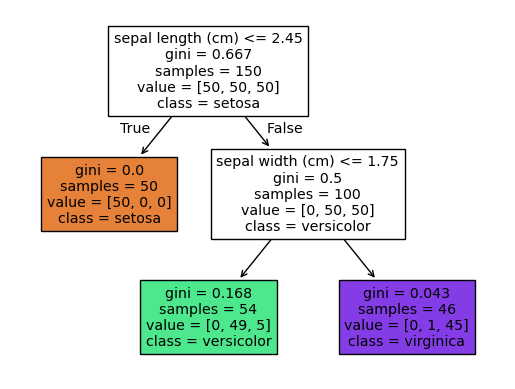

In [21]:
#import matplotlib as plt
from sklearn import tree
graph = tree.plot_tree(tree_model,
                   feature_names=iris.feature_names,
                   class_names=iris.target_names,
                   filled=True)

# 1.2 Complete Example with Iris

Now, let's consider a complete workflow on how to handle the iris dataset. This is typically what
we do with any other dataset when it comes to machine learning i.e. load the dataset, explore and
visualise it, handle missing values, and creating and evaluating the models.


**1.2.1 Load Data**

First, and instead of what you have done above, you can also load and save the data into a pandas
data frame, explore it, and then can save it locally at your machine. Let's do this, and quickly
explore the data

In [22]:
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris()
df = pd.DataFrame(iris['data'], columns=iris['feature_names'])
df['target'] = iris['target']
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


**1.2.2 Add/Drop Columns**

Let's add one more column to the dataset and we will call it **Species** and drop the *target column*.
Usually when building a machine learning algorithm, it is better to have the target variable represented as a number, but here, we want to represent it as a string, just for clarity, and also to show
how can we add/ drop columns from a data frame in Python.


In [23]:
# add a new column to the dataset
df['Species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [24]:
# drop the target name
df.drop(['target'],axis=1,inplace=True)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [25]:
# lets change the columns names in the dataset
df.columns = ['sLength','sWidth','pLength','pWidth','Species']
df.head()

,sLength,sWidth,pLength,pWidth,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**1.2.3 Save Data**

Lets save a copy of the data locally. The lines of code below, stores the dataset into a folder called
*data*, notice that this folder is outside the folder that contains the notebook. In other words,
imagine that this notebook (your notebook) is stored in a folder called *week05/lab/DecisionTrees.ipynb*, then your data folder will need to be in *week05/Data*, and so your iris dataset
path will be *week05/data/iris.csv*.

In [27]:
# You might want some code to make the directory. 
# But if you do this, it will fail if the directory exists.
# You can also make the directory from within Windows Explorer.

#import os
#os.mkdir("../data")


# set index to false to prevent pandas from adding extra column to your dataset
df.to_csv('../data/iris.csv',index = False)
# if needed you can always reload the dataset as follows
df = pd.read_csv('../data/iris.csv')
df.head()

,sLength,sWidth,pLength,pWidth,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**1.2.4 Data Exploration**

Similar to what we have done in the past four weeks, first thing when we deal with a dataset,
is to thoroughly explore it, and apply some data pre-processing methods before we feed it into a
machine leaning algorithm such as SVM, or Decision Tree in this case. Let's start with some data
exploration.


**Class Distribution**: It is always important to check the class distribution in your dataset. Remember, the class label or the (dependant variable) is the one that we are trying to learn. So one
of the first steps to do is to see how it is distributed in the dataset:

In [28]:
# class labels distribution
df['Species'].value_counts()

Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

As can be seen above, we have 150 instances representing flowers with 50 instances per each type.
You can also visualise the class distribution as follows:

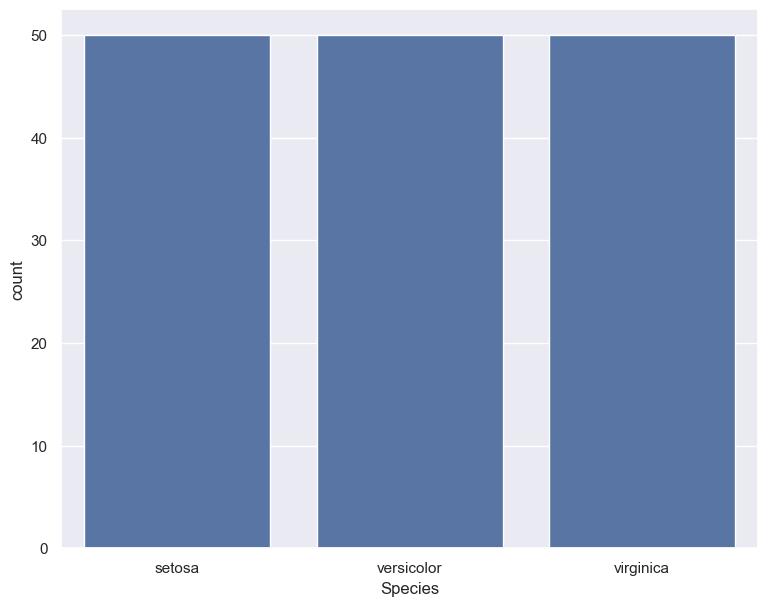

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
sns.set(rc={'figure.figsize':(9,7)})
sns.countplot(x="Species", data=df)
plt.show()

**Summary Statistics** Box plots are very useful, and we can use them to explore the range of
values of each feature (column). The code below shows the average Sepal Length of each flower
instance in the dataset, grouped by the type of flower (Species).

* Change the variable sLength" in the line of code below to explore other features i.e. sWidth,
pLength, pWidth, and check the results What can you say about this?

* Recall that a Box Plot shows five numbers that summarise the data. These are the minimum
value, first quartile, median, third quartile and max value.

<Axes: xlabel='Species', ylabel='sLength'>

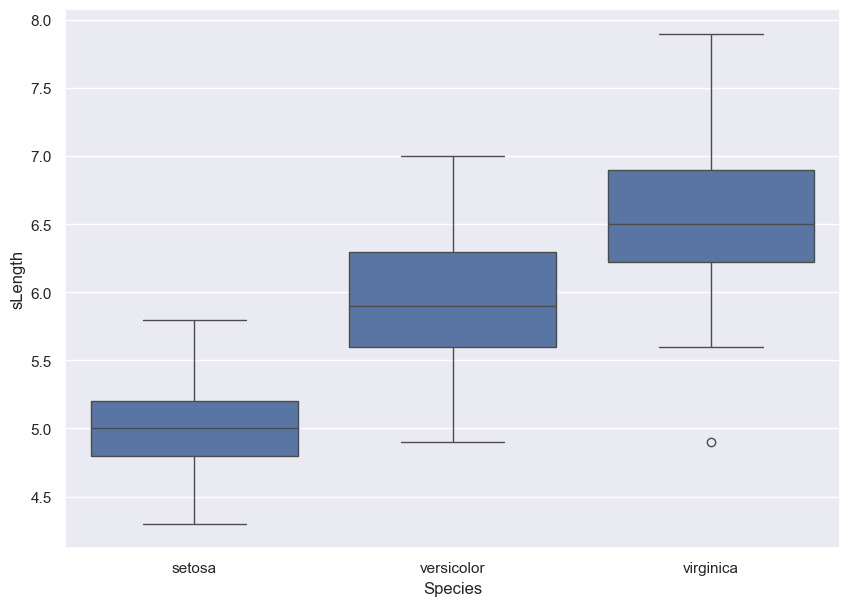

In [31]:
plt.figure(figsize=(10,7))
sns.boxplot(data=df,x='Species',y='sLength')

Let's plot all variables (four columns in the dataset) to see how the categorical feature Species is
distributed across all other four input features:

<Axes: xlabel='Species', ylabel='pWidth'>

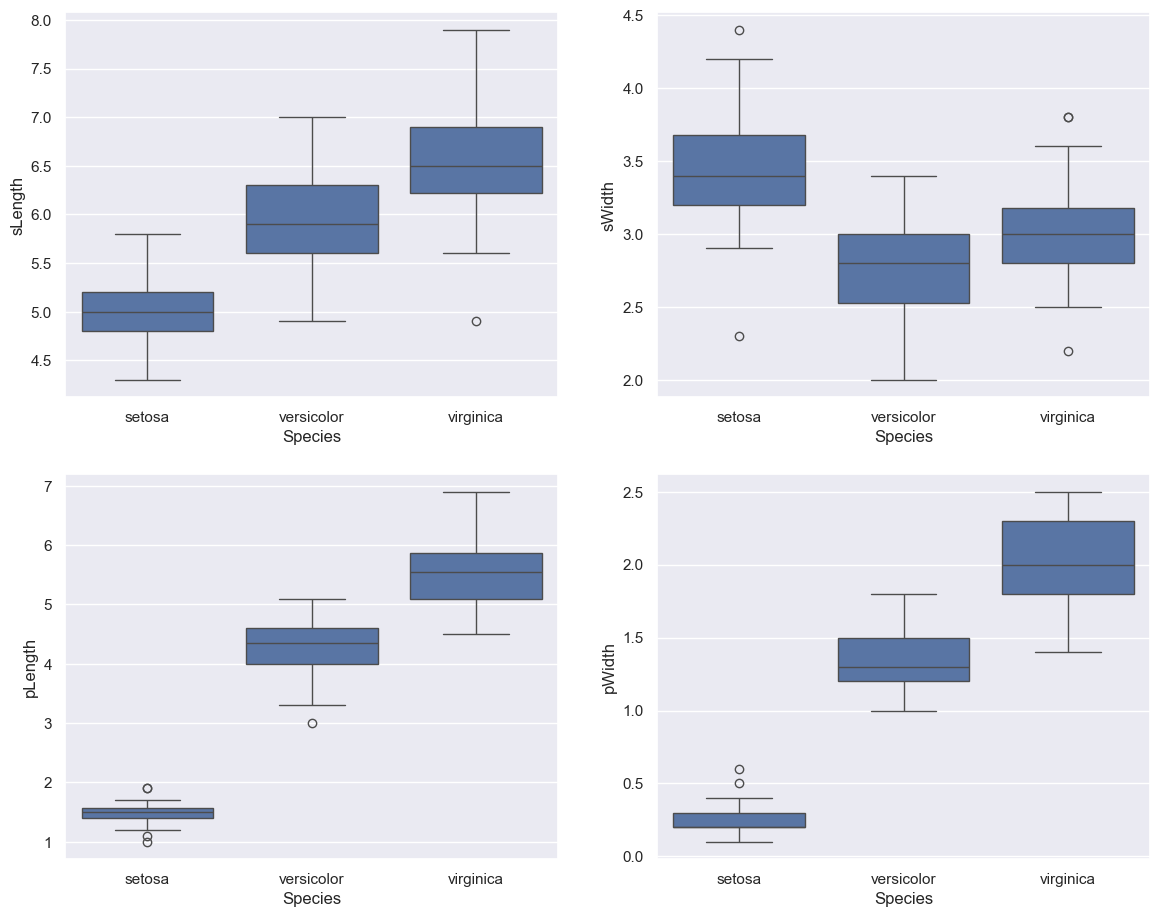

In [32]:
# make four subplots - one for each feature.
plt.figure(figsize=(14,11))
# first subplot (nrows, ncols, position)
plt.subplot(2,2,1)
sns.boxplot(x='Species',y='sLength',data=df)
# second
plt.subplot(2,2,2)
sns.boxplot(x='Species',y='sWidth',data=df)
# third
plt.subplot(2,2,3)
sns.boxplot(x='Species',y='pLength',data=df)
# fourth
plt.subplot(2,2,4)
sns.boxplot(x='Species',y='pWidth',data=df)

**Correlations** It is important to gain insight about the relationships between features in the
dataset. We can show the variables pairs in the dataset using **pair plot**. This is a useful way to
explain the relationships between features in your dataset and also helps determine the type of
analysis you want to follow. Notice the diagrams below, you can easily determine many linear
relationships between variables. Pandas can also use the .corr() function to quantify variable correlations.

Let's first get some insights to understand more about the relation between specific variables
(columns/ features) such as sLength, sWidth, pWidth.

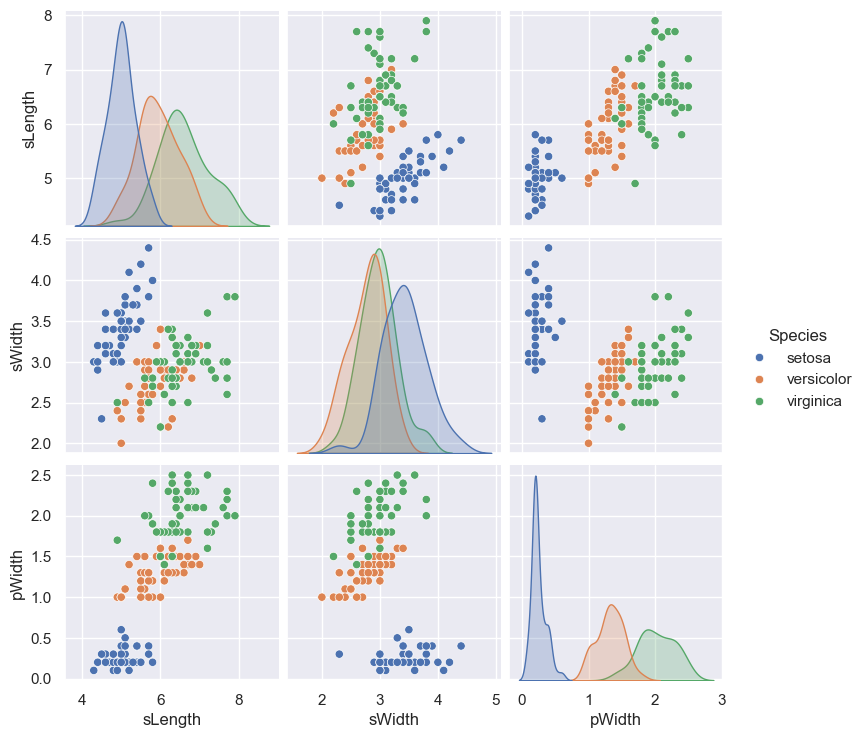

In [33]:
# columns to plot
cols_names =['sLength','sWidth','pWidth','Species']
sns.pairplot(df[cols_names], hue="Species")
#plt.show()

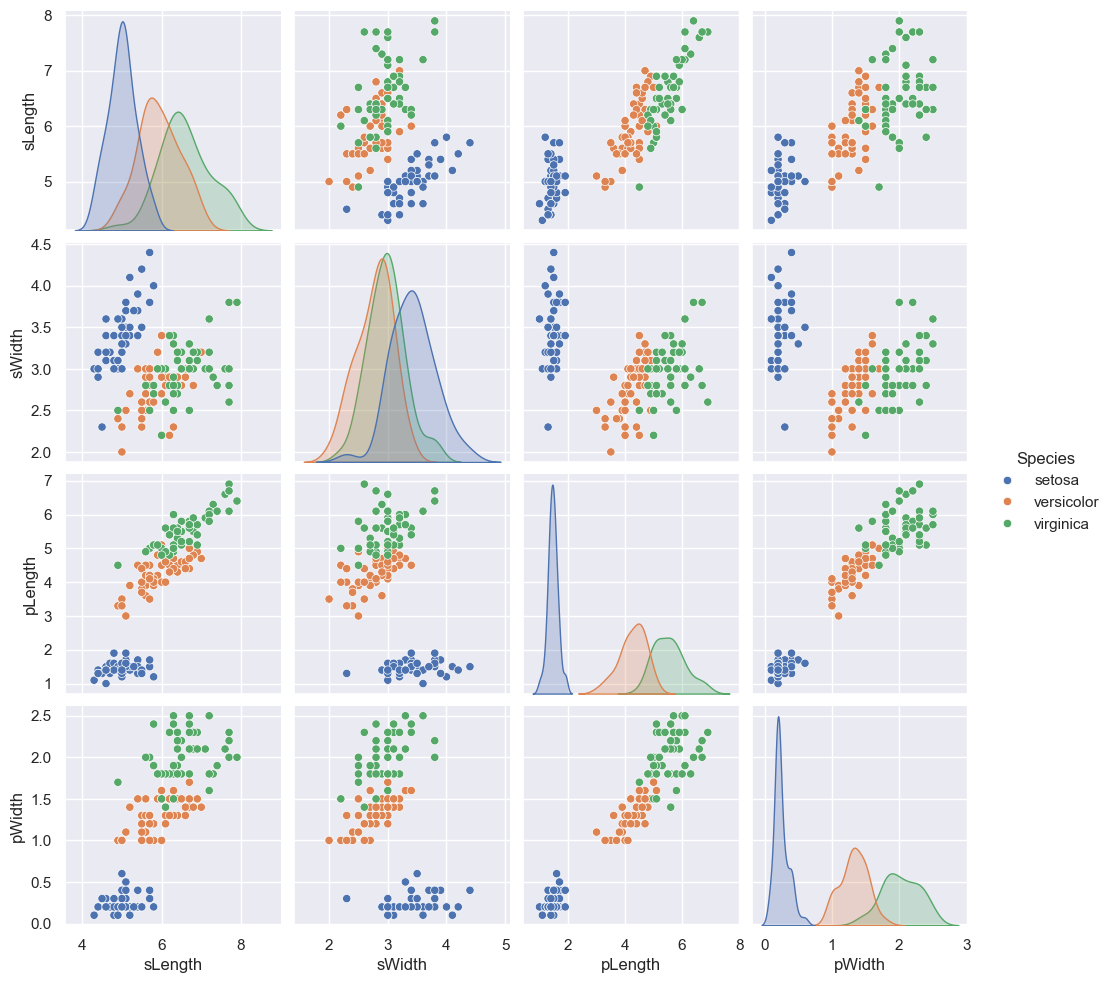

In [34]:
# plot relatoins between features
sns.pairplot(df, hue="Species")


Spend a little time with the plot and try to understand what it means. The colours are the species, the diagonal is a histogram. The scatter plots show two variables together. It shows how nicely the individual classes cluster, or how overlapped two classes are in terms of those features.

Experiment and see what removing the hue feature does.

It should be noted that:

* The diagonal contains histogram of each feature. For example, top left histogram shows how
many examples from the dataset contains specfic sLength (distribution of sLengths across
all instances in the dataset)

* You can also see some strong correlation between several variables

One more technique to use is the Scatter Plots between two features. Scatter plots are also very
useful to understand the type of relations between two variables in your dataset. Below, we plot
the **pLength** against the **pWidth** variables across all instances in the dataset. Again you can see
strong linear trend in the diagram. Change the variables below to explore relations (use the pandas dataframe column names or pick up the names from the pairplot above).

[Text(0.5, 0, 'Petal Length'), Text(0, 0.5, 'Petal Width')]

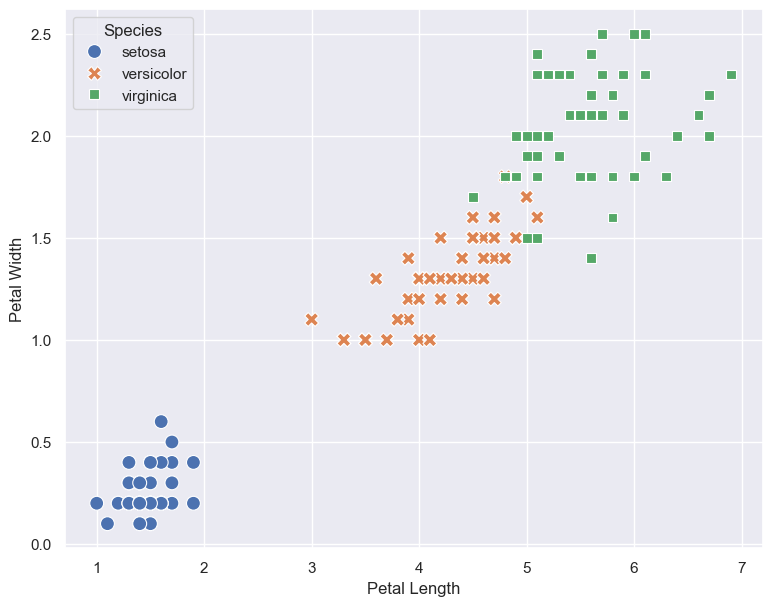

In [35]:
# set variables, size and size of the markers of the plot
ax = sns.scatterplot(x='pLength', y="pWidth", data=df, hue='Species', style='Species',s=100)
ax.set(xlabel='Petal Length', ylabel='Petal Width')

A very simple technique to uncover correlations between variables is also to compute the standard
correlation coefficient (often called *Pearson’s r*) between every pair of variables in your dataset.
This can be easily achieved as follows. Notice that you need a dataframe with only numbers in it. You could replace the labels with dummy variables to fake this, but you should only do that if the labels are ordinal (i.e. they have some sort of natural order - flowers don't).

In [38]:
df_numbers_only = df[["sLength", "sWidth", "pLength", "pWidth"]]
display(df_numbers_only)

# compute correlations
cor_matrix = df_numbers_only.corr()
print("Correlation (Pearson) matrix")
cor_matrix

,sLength,sWidth,pLength,pWidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


Correlation (Pearson) matrix


,sLength,sWidth,pLength,pWidth
sLength,1.000000,-0.117570,0.871754,0.817941
sWidth,-0.117570,1.000000,-0.428440,-0.366126
pLength,0.871754,-0.428440,1.000000,0.962865
pWidth,0.817941,-0.366126,0.962865,1.000000


You can also visualise the correlation using a *heatmap*:

[]

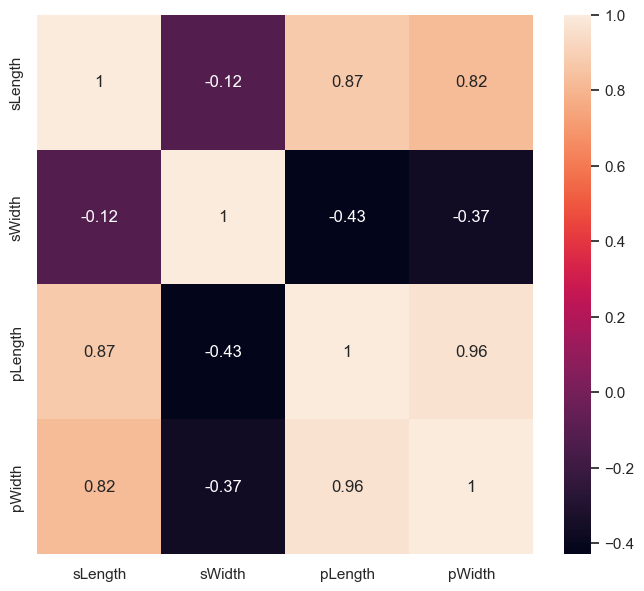

In [48]:
ax = plt.figure(figsize=(8,7))
ax = sns.heatmap(cor_matrix,annot=True)
ax.set_ylim(sorted(ax.get_xlim(), reverse=True))
plt.plot()

The correlation coefficients can range from -1 to 1 (although ours do not use the full range). If it is close to 1, it means that there is a strong correlation between the two features (i.e. a feature correlation with itself is 1 and would plot a perfect diagonal, straight line on a graph), and as the
coefficient goes to -1 it means strong negative correlation (inverse diagonal line). While a value close to 0, means that there is no correlation between the two features. For example, it is clear from the table above that no real correlation between sLength and sWidth, as the value is close to zero −0.117570. This is also evident by the scatter plot between these two variables as can be seen below:

[Text(0.5, 0, 'Sepal Length'), Text(0, 0.5, 'Sepal Width')]

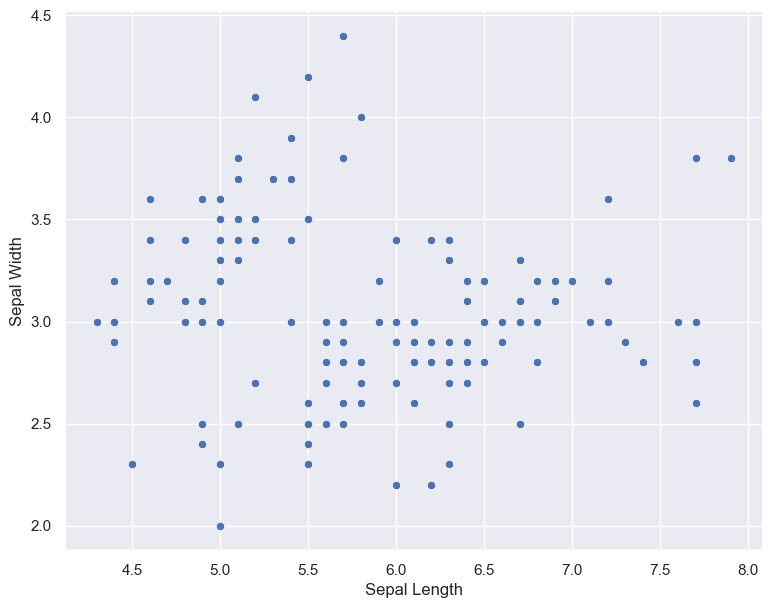

In [39]:
ax = sns.scatterplot(x='sLength', y="sWidth", data=df)
ax.set(xlabel='Sepal Length', ylabel='Sepal Width')

On the other hand, a strong correlation of 0.962865 exists between *pLength* and *pWidth*. Notice,
that if you plot these two variables, such strong relation is very visible. In other words as you
increase pLength, then pWidth increases (it forms a fairly obvious diagonal line of points).

[Text(0.5, 0, 'Petal Length'), Text(0, 0.5, 'Petal Width')]

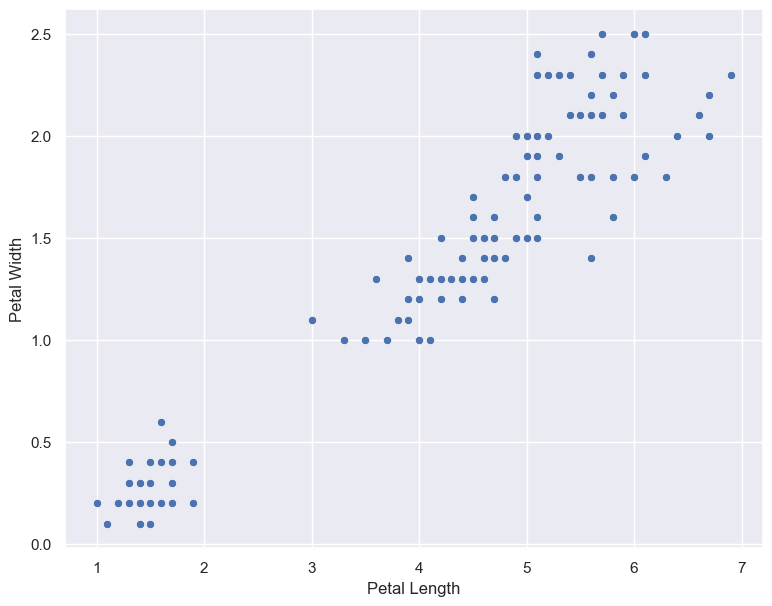

In [40]:
ax = sns.scatterplot(x='pLength', y="pWidth", data=df)
ax.set(xlabel='Petal Length', ylabel='Petal Width')

Another way to show this strong linear relation between the above two features, is to use the
*lmplot()* function which plots a linear regression model (i.e. it fits a line to the data).

Notice that "col" is column of the plot, hue is the colour. See what happens if you remove the hue variable and the col variable. See which makes the "nicer" plot.

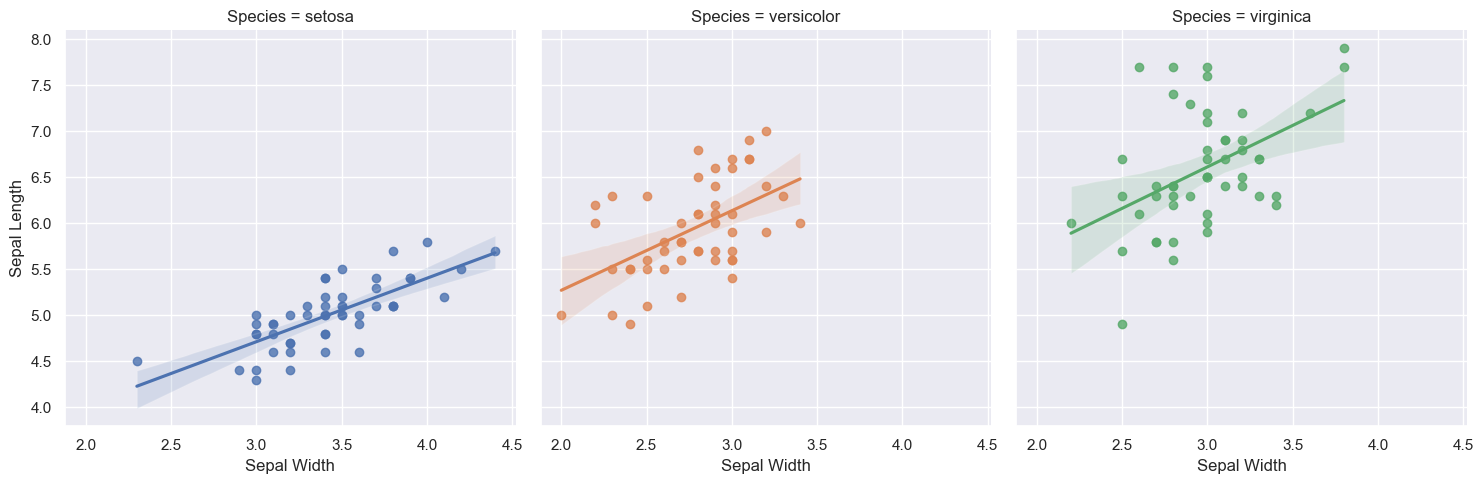

In [41]:
ax = sns.lmplot(x = 'sWidth', y = 'sLength', data = df, col = 'Species', hue ='Species')
ax.set(xlabel='Sepal Width', ylabel='Sepal Length')

**Final word about correlation**: Although this step is not important in the case of **iris** dataset, we
often want to drop the highly correlated features, before proceeding with our analysis. One way
to identify the highly correlated features in your dataset as follows:

In [44]:
# create correlation matrix (ignore the sign)
corr_matrix = df_numbers_only.corr().abs()
corr_matrix

,sLength,sWidth,pLength,pWidth
sLength,1.000000,0.117570,0.871754,0.817941
sWidth,0.117570,1.000000,0.428440,0.366126
pLength,0.871754,0.428440,1.000000,0.962865
pWidth,0.817941,0.366126,0.962865,1.000000


In [45]:
# get the upper triangle of the matrix
import numpy as np
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))
upper

,sLength,sWidth,pLength,pWidth
sLength,NaN,0.11757,0.871754,0.817941
sWidth,NaN,NaN,0.428440,0.366126
pLength,NaN,NaN,NaN,0.962865
pWidth,NaN,NaN,NaN,NaN


In [47]:
# Find features with correlation coefficient > 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f'The feature that you can drop is {to_drop}')

The feature that you can drop is ['pWidth']


# 1.3 Data Preparation

Once you have gained enough insight about the dataset, it is important to get it ready and prepared
before fitting your machine learning algorithms and evaluating performance.


**Missing Values** Clearly, the first step is to handle any missing values. With Iris there are no missing values, but you should always check for any missing values. It should be noted that Scikit-Learn provides an easy way to handle missing values using SimpleImputer. This can be achieved easily by
first creating a SimpleImputer instance, and specifying that you want to replace each attribute’s
(column) missing values with the median of that column. Notice here, that the imputer only applies for numerical attributes, so as in the correlation matrix, I will just use a sub data frame with only numercial values for the purpose of illustration in this section.


In [55]:
df_numbers_only = df[["sLength", "sWidth", "pLength", "pWidth"]]
df_numbers_only.head()

,sLength,sWidth,pLength,pWidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Recall that iris has no missing values, so let's insert some missing values in the df_numbers_only dataset
(which is a subset of iris). We will change all the values of sWidth to None if sLength=5.0, this
should result in 10 missing values across the column sWidth


In [57]:
df_numbers_only.loc[(df_numbers_only['sLength'] ==5.0), 'sWidth'] = None
df_numbers_only.head() # Look for the new NaN value.

,sLength,sWidth,pLength,pWidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,NaN,1.4,0.2


In [59]:
# check missing values now
df_numbers_only.isnull().sum()

sLength     0
sWidth     10
pLength     0
pWidth      0
dtype: int64

Let's handle the missing values using the SimpleImputer as discussed above.

In [60]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
imputer.fit(df_numbers_only)

SimpleImputer(strategy='median')

Here, the imputer computed the median value of each attribute (column) in our dataset num_df,
then replace missing values of the corresponding column with the computed value. Here, only
the sWidth contains missing values and hence would be replaced. You can check these computed
values in the imputer statistics_ variable as follows:

In [61]:
imputer.statistics_

array([5.8 , 3.  , 4.35, 1.3 ])

You should know which value of the above was used to impute the missing values in our
column sWidth (sWidth was the second column along, the imputer stats are in the same order).

Now, you can use the imputer to transform the dataset by replacing its missing values with
the above values:


In [63]:
# num_df_imputed is of type Numpy Array
num_df_imputed = imputer.transform(df_numbers_only)

## Turn the numbers only back into a dataframe taking the column names from the old dataframe
num_DF = pd.DataFrame(num_df_imputed, columns=df_numbers_only.columns, index =df_numbers_only.index)
num_DF.head()

,sLength,sWidth,pLength,pWidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.0,1.4,0.2


You should see now that we have no missing values in our dataset

In [64]:
num_DF.isnull().sum()

sLength    0
sWidth     0
pLength    0
pWidth     0
dtype: int64

**Data Cleaning** This is one of the most demanding steps in your workflow, it often includes:

* Getting rid of some unwanted variables (i.e. patient-id, student-id, highly correlated variables
and so on),

* scaling features,

* changing categorical variables to dummy variables and other tasks. 

We covered some of these in previous labs, and will continue to do so in the coming labs as well.
In iris dataset however, we don’t have to do much cleaning to the data, though we need always to
check for all these consideration. So, we will move to the creation and evalution of our model.

# 1.4 Decision Tree Model

Recall, we want to build a model that is able to classify flowers based on their sepal and petal
lengths and width into three different species. The dataset looks like this:

In [65]:
df.head()

,sLength,sWidth,pLength,pWidth,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [66]:
# Import the libraries
import pandas as pd
from sklearn.model_selection import train_test_split
# Import LabelEncoder
from sklearn import preprocessing

We want to turn labels into numbers to make the data processing easier.

In [67]:
# create label ecnoder to encode the labels (setosa, ...) into integers
le = preprocessing.LabelEncoder()

# Converting string labels into numbers
df.Species = le.fit_transform(df.Species)
# check the data now
df.head()

,sLength,sWidth,pLength,pWidth,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [68]:
# split the data into Features and Label (X, y)
features = ['sLength','sWidth','pLength','pWidth']
X = df[features]# returns data frame
y = df['Species']

You can perform the above operation using slightly different approach as shown below. The key
difference here, is that X in this case will be a numpy array rather than a data frame as above

`X = df.iloc[:, :-1].values y = df.iloc[:, 4].values`

**Data Split**: Now, let's split the data into training and testing sets using the Scikit-Learning library.
We will use 80% of the data for training our model and the rest for testing. If you check the
`X_train.shape` you will notice that we are using 120 training example for the training


In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)
print ('The shape of the training set is ' ,X_train.shape)

The shape of the training set is  (120, 4)


**Create Model**: Now, the next step is to make an instance of the model. In the code below, we
set the maximum depth to 2 (`max_depth=2`). This will ensure that the tree can’t go deeper than
level 2. Setting the random_state = 0 is to ensure that you can get same results of you re-run this
experiment (results reproducibility).

In [70]:
# create an instance of the decision tree model
clf = DecisionTreeClassifier(max_depth = 2, random_state = 0)

**Train**: The next step is to use our data in the training set X_train to train our model to learn the relationship between the X which represents the input features (four columns), and the y representing the *Species* of the instance:

In [71]:
# train the model (notice the parameters of the DecisionTreeClassifier)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=0)

**Make Predictions**: Now, to test our model’s performance, we use the testing set to make predictions as shown below:

* Notice that you can make a prediction for one instance (example)

* Make predictions for more than one instance

* Predictions for the whole testing set

In [84]:
# Prediction for one instance (first one in the testing set)
label0 = clf.predict(X_test[0:1])
print(X_test[0:1])
print(label0)

# Predictions for the 10 instances in the testing set
labels_1_to_10= clf.predict(X_test[0:10])
print(X_test[0:10])
print(labels_1_to_10)

# Predictions for the whole testing set
predictions = clf.predict(X_test)

     sLength  sWidth  pLength  pWidth
114      5.8     2.8      5.1     2.4
[2]
     sLength  sWidth  pLength  pWidth
114      5.8     2.8      5.1     2.4
62       6.0     2.2      4.0     1.0
33       5.5     4.2      1.4     0.2
107      7.3     2.9      6.3     1.8
7        5.0     3.4      1.5     0.2
100      6.3     3.3      6.0     2.5
40       5.0     3.5      1.3     0.3
86       6.7     3.1      4.7     1.5
76       6.8     2.8      4.8     1.4
71       6.1     2.8      4.0     1.3
[2 1 0 2 0 2 0 1 1 1]


**Model’s Performance**: As discussed in previous lectures, there are various evaluation metrics that
we can use to evaluate our model. However, here we will only use the accuracy in this instance.

In [85]:
# Get the model's accuracy
accuracy = clf.score(X_test, y_test)
print(f'The Model Accuracy is {round(accuracy*100,2)}%')

The Model Accuracy is 96.67%


**Hyper-parameter Tuning**: As we did with other learning algorithms (i.e. SVM last week), we can always improve the model’s performance by tuning hyper parameters. One of these parameters is the maximum depth of the tree:


In [88]:
# We can manually try various values:
max_depth_vals = list(range(1, 10))
# We need a list to store the accuracy for each model with different max depth
# List to store the average RMSE for each value of max_depth:
accuracy_list = []
# Try different max depth values above
for max_depth in max_depth_vals:
    # create the model with specific max depth
    clf = DecisionTreeClassifier(max_depth = max_depth,
    random_state = 0)
    # fit the data
    clf.fit(X_train, y_train)
    # get accuracy and store it in the list accuracy
    accuracy = clf.score(X_test, y_test)
    accuracy_list.append(accuracy)
    print("Accuracy for max_depth {} is {}".format(max_depth, accuracy))

Accuracy for max_depth 1 is 0.5666666666666667
Accuracy for max_depth 2 is 0.9666666666666667
Accuracy for max_depth 3 is 0.9666666666666667
Accuracy for max_depth 4 is 1.0
Accuracy for max_depth 5 is 1.0
Accuracy for max_depth 6 is 1.0
Accuracy for max_depth 7 is 1.0
Accuracy for max_depth 8 is 1.0
Accuracy for max_depth 9 is 1.0


Notice that with max_depth=0, the results are poor, however as you increase the level of depth, you reach 100% accuracy. It should be noted that you should be careful when you get 100%, as the model might be overfitting. We can plot a curve that shows the accuracy according to the max_depth values above. First let's put result in one data frame using the code below:

In [89]:
# create list of tuples (pairs of depth and accuracy)
depth_accuracies = list(zip(max_depth_vals,accuracy_list))
# create a data frame
results = pd.DataFrame(data=depth_accuracies, columns=['max_depth','accuracy'])
results

,max_depth,accuracy
0,1,0.566667
1,2,0.966667
2,3,0.966667
3,4,1.000000
4,5,1.000000
5,6,1.000000
6,7,1.000000
7,8,1.000000
8,9,1.000000


[Text(0.5, 0, 'Tree Depth'), Text(0, 0.5, 'Accuracy')]

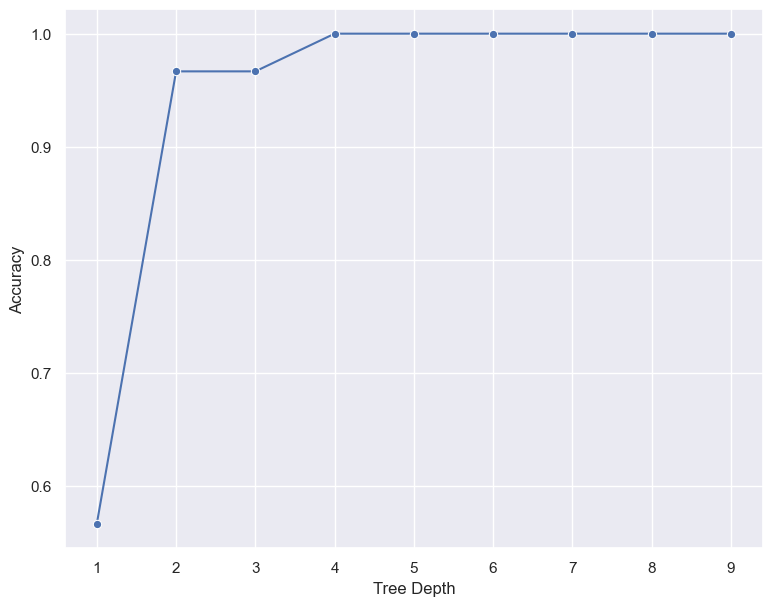

In [90]:
# Plot the graph
ax = sns.lineplot(x="max_depth", y="accuracy", data=results, marker="o")
ax.set(xlabel='Tree Depth', ylabel='Accuracy')

**Features Importance** We discussed one important aspect of decision tree in the lecture which is feature importance. Using Scikit-Learn, we can compute the feature importance which is the total **gini* decrease due to splits over a given feature. Below, is the code that shows features importances in our decision tree model. Notice that values are normalised between 0 and 1:

In [91]:
# create data frame to store features importances
importances = pd.DataFrame({'feature':X_train.columns,'importance':np.round(clf.feature_importances_,3)})

# sort the data frame by importance attribute
importances = importances.sort_values('importance',ascending=False)
# show results
importances

,feature,importance
3,pWidth,0.923
2,pLength,0.064
1,sWidth,0.013
0,sLength,0.000


Few things to note about the above results. First pWidth has the highest feature importance
weight. Second, it doesn’t mean that if a feature importance is too low i.e. sLength in this case,
that this feature is not important for prediction (remember, pWidth and pLength were strongly correlated, so they should have similar feature importance, but once a decision node has been made using pWidth, pLength becomes a lot less important), more about this can be found at [Scikit-Learn documentation](https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html).

# 1.5 Closing Remarks

In this tutorial, we covered wide range of techniques related to data exploration, visualisation and
finally modelling with Decision Trees using Scikit-Learn. The iris dataset we used today is simple,
so in fact it doesn’t’ require much pre-processing and exploration to build a classification model
that is mapping the features input space into the target variable Species. However, in most real-world datasets, we often spend major part of the time on exploring and preparing the datasets
before actually creating our Machine Learning Algorithms. There are plenty of resources and
online Notebooks that presents different techniques for exploring and pre-processing datasets. In
particular, I would recommend you look at Kaggle's notebooks (although please do not plagiarise Kaggle notebooks for your coursework!).